In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
customers = pd.read_csv("Customer_Master_Data.csv")
transactions = pd.read_csv("Customer_Transactions.csv")

print("Customers Shape:", customers.shape)
print("Transactions Shape:", transactions.shape)

customers.head()

Customers Shape: (1000, 9)
Transactions Shape: (23050, 3)


,CustomerID,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate
0,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22
1,CUST10001,Divit Kohli,mkalita@sarin.com,Female,48,Kolkata,Married,0,2023-12-06
2,CUST10002,Kiara Behl,apteanay@hotmail.com,Male,75,Kolkata,Widowed,2,2023-08-23
3,CUST10003,Vaibhav Sankar,bseshadri@choudhry.info,Male,62,Pune,Divorced,2,2022-11-17
4,CUST10004,Shray D’Alia,bdhillon@toor-mall.com,Male,55,Delhi,Divorced,0,2022-12-04


In [3]:
transactions.head()

,CustomerID,TransactionDate,TransactionAmount
0,CUST10771,7/31/23,2383.07
1,CUST10100,3/10/24,497.54
2,CUST10031,2/17/25,536.78
3,CUST10987,7/17/23,314.89
4,CUST10831,12/15/24,2543.19


In [4]:
# Converting date columns
customers['JoinDate'] = pd.to_datetime(customers['JoinDate'])

transactions['TransactionDate'] = pd.to_datetime(
    transactions['TransactionDate'],
    format='%m/%d/%y')

# Removing duplicate customers
customers.drop_duplicates(subset='CustomerID', inplace=True)

# Checking missing values
print("Customer Missing Values")
print(customers.isnull().sum())

print("\nTransaction Missing Values")
print(transactions.isnull().sum())

Customer Missing Values
CustomerID       0
Name             0
Email            0
Gender           0
Age              0
City             0
MaritalStatus    0
NumChildren      0
JoinDate         0
dtype: int64

Transaction Missing Values
CustomerID           0
TransactionDate      0
TransactionAmount    0
dtype: int64


In [5]:
valid_ids = transactions['CustomerID'].isin(customers['CustomerID'])
print("Invalid Customer IDs:", (~valid_ids).sum())

Invalid Customer IDs: 0


In [6]:
df = pd.merge(
    transactions,
    customers,
    on='CustomerID',
    how='left')

df.head()

,CustomerID,TransactionDate,TransactionAmount,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate
0,CUST10771,2023-07-31,2383.07,Lakshay Dhillon,dharmajantara@gmail.com,Female,27,Ahmedabad,Widowed,3,2023-05-31
1,CUST10100,2024-03-10,497.54,Aniruddh Borah,jivikabhavsar@gmail.com,Female,53,Lucknow,Divorced,4,2022-01-08
2,CUST10031,2025-02-17,536.78,Ritvik Ahuja,jhaverifarhan@chandra.org,Male,40,Ahmedabad,Single,0,2023-12-03
3,CUST10987,2023-07-17,314.89,Jayan Wagle,ojas82@gmail.com,Not Disclosed,75,Bangalore,Widowed,4,2022-03-18
4,CUST10831,2024-12-15,2543.19,Ishita Agarwal,vbalay@yahoo.com,Not Disclosed,27,Jaipur,Divorced,4,2021-06-30


In [9]:
reference_date = transactions['TransactionDate'].max() + pd.Timedelta(days=1)

rfm = transactions.groupby('CustomerID').agg({
    'TransactionDate': lambda x: (reference_date - x.max()).days,
    'CustomerID': 'count',
    'TransactionAmount': 'sum'})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
CUST10000,13,23,21265.49
CUST10001,35,30,28654.31
CUST10002,18,24,23884.03
CUST10003,81,25,24206.03
CUST10004,8,19,25565.30


In [10]:
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    5,
    labels=[5,4,3,2,1])

rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1,2,3,4,5])

rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    5,
    labels=[1,2,3,4,5])

rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str)
    + rfm['F_Score'].astype(str)
    + rfm['M_Score'].astype(str))

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
CUST10000,13,23,21265.49,4,3,2,432
CUST10001,35,30,28654.31,3,5,5,355
CUST10002,18,24,23884.03,4,3,3,433
CUST10003,81,25,24206.03,1,4,3,143
CUST10004,8,19,25565.30,5,1,4,514


In [12]:
def segment(row):

    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    elif f >= 4 and r >= 2:
        return "Loyal Customers"
    elif r >= 4 and f >= 2:
        return "Potential Loyalist"
    elif r <= 2 and f >= 3:
        return "At Risk"
    elif r == 1:
        return "Lost"
    else:
        return "Others"

rfm['Segment'] = rfm.apply(segment, axis=1)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
CustomerID,,,,,,,,
CUST10000,13,23,21265.49,4,3,2,432,Potential Loyalist
CUST10001,35,30,28654.31,3,5,5,355,Loyal Customers
CUST10002,18,24,23884.03,4,3,3,433,Potential Loyalist
CUST10003,81,25,24206.03,1,4,3,143,At Risk
CUST10004,8,19,25565.30,5,1,4,514,Others


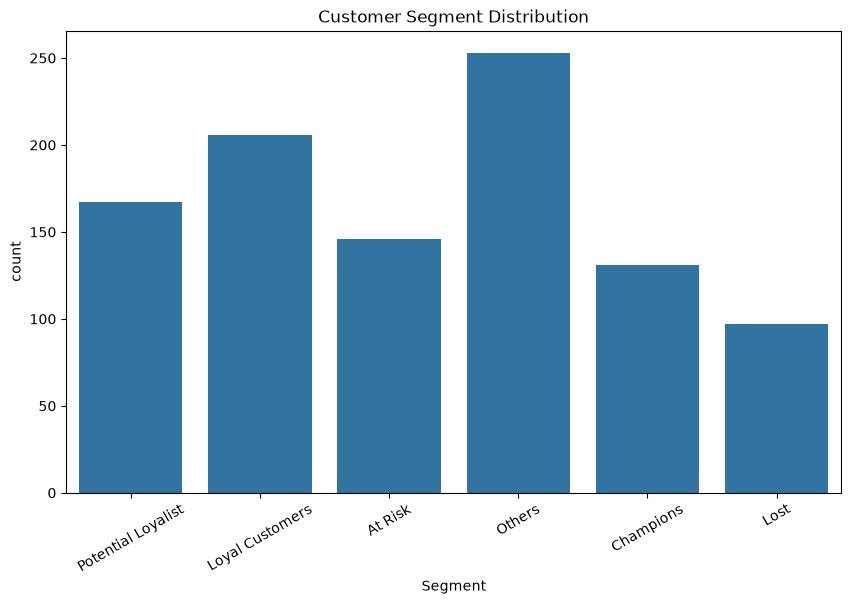

In [13]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=rfm,
    x='Segment')
plt.title("Customer Segment Distribution")
plt.xticks(rotation=30)
plt.show()

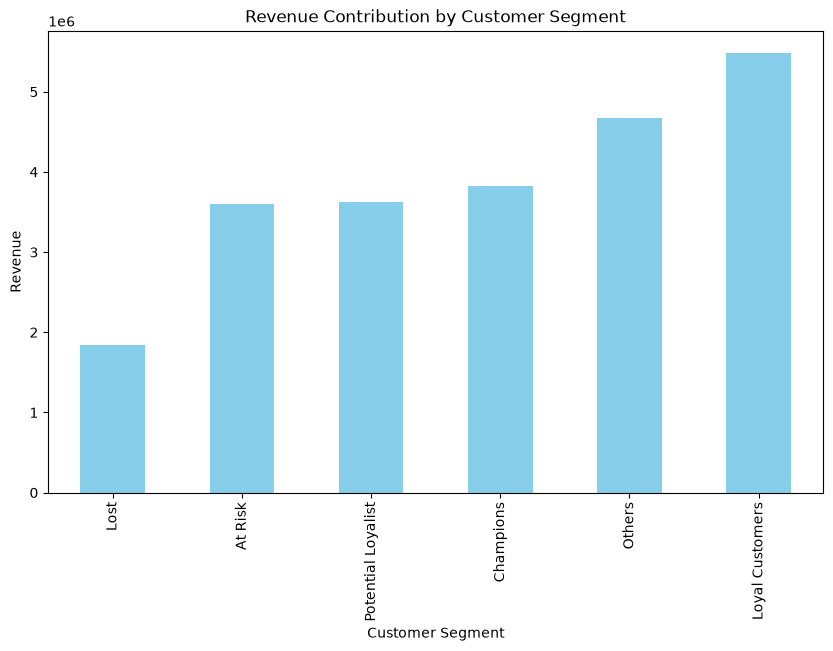

In [14]:
plt.figure(figsize=(10,6))

rfm.groupby('Segment')['Monetary'].sum().sort_values().plot(
    kind='bar',
    color='skyblue')
plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue")
plt.show()

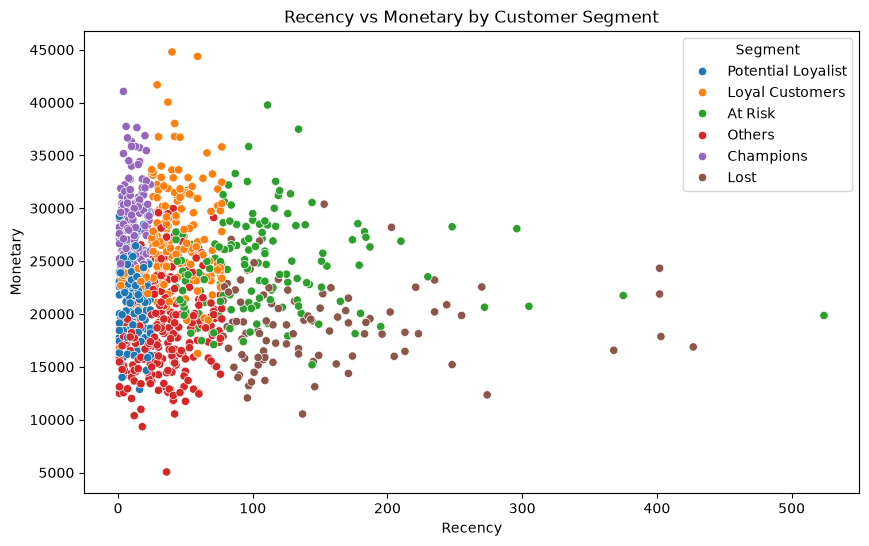

In [15]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Segment')

plt.title("Recency vs Monetary by Customer Segment")
plt.show()

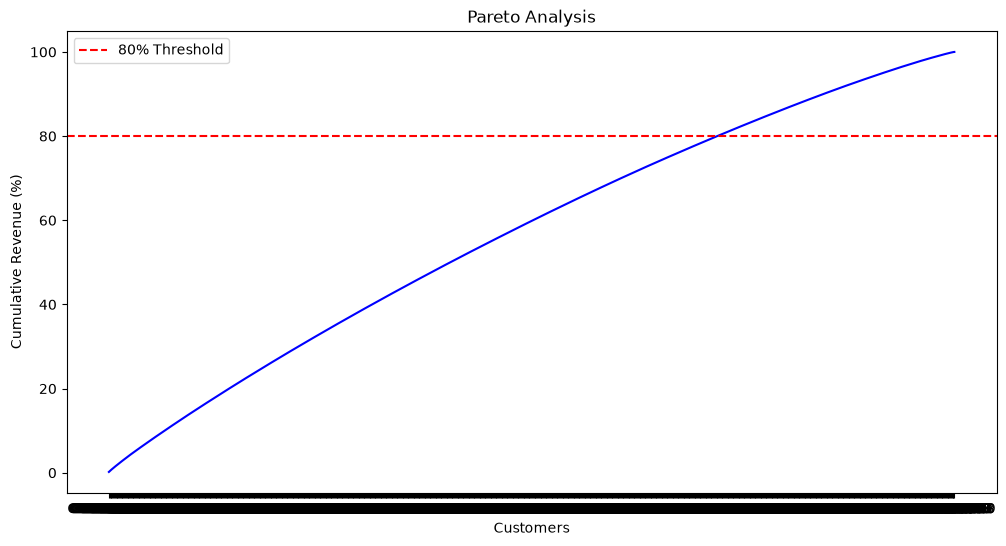

In [16]:
rfm_sorted = rfm.sort_values(
    by='Monetary',
    ascending=False)

rfm_sorted['Cumulative Revenue'] = rfm_sorted['Monetary'].cumsum()

rfm_sorted['Cumulative Percentage'] = (
    100 *
    rfm_sorted['Cumulative Revenue'] /
    rfm_sorted['Monetary'].sum())

plt.figure(figsize=(12,6))

plt.plot(
    rfm_sorted['Cumulative Percentage'],
    color='blue')

plt.axhline(
    y=80,
    color='red',
    linestyle='--',
    label='80% Threshold')

plt.title("Pareto Analysis")
plt.xlabel("Customers")
plt.ylabel("Cumulative Revenue (%)")
plt.legend()

plt.show()

In [17]:
print("Top 5 Customers by Revenue")
print(rfm.sort_values(by='Monetary', ascending=False).head())

print("\nCustomer Segments")
print(rfm['Segment'].value_counts())

print("\nAverage Monetary Value")
print(rfm['Monetary'].mean())

print("\nAverage Frequency")
print(rfm['Frequency'].mean())

print("\nAverage Recency")
print(rfm['Recency'].mean())

Top 5 Customers by Revenue
            Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Score  \
CustomerID                                                                   
CUST10944        40         31  44784.99       3       5       5       355   
CUST10510        59         30  44367.33       2       5       5       255   
CUST10053        29         30  41674.56       3       5       5       355   
CUST10776         4         33  41050.76       5       5       5       555   
CUST10696        37         30  40035.48       3       5       5       355   

                    Segment  
CustomerID                   
CUST10944   Loyal Customers  
CUST10510   Loyal Customers  
CUST10053   Loyal Customers  
CUST10776         Champions  
CUST10696   Loyal Customers  

Customer Segments
Segment
Others                253
Loyal Customers       206
Potential Loyalist    167
At Risk               146
Champions             131
Lost                   97
Name: count, dtype: int64

Averag

## Pareto Analysis Conclusion

The Pareto Analysis shows that a relatively small percentage of customers contributes to approximately **80% of the total revenue**, demonstrating the **Pareto (80/20) Principle**. This insight highlights the importance of identifying and retaining high-value customers through personalized marketing, loyalty programs, and targeted retention strategies. Focusing on these customers can significantly improve revenue growth, customer lifetime value, and overall business performance.

# Business Insights

1. The majority of customers fall into the **Others** and **Loyal Customers** segments, indicating a diverse customer base with opportunities for increased engagement.

2. **Champions** contribute a significant portion of total revenue despite representing a smaller percentage of customers, making them the most valuable customer segment.

3. Customers categorized as **At Risk** should be prioritized with personalized offers, loyalty rewards, and retention campaigns to reduce customer churn.

4. The **Pareto Analysis** reveals that a relatively small percentage of customers generates the majority of the company's revenue, supporting the **80/20 Principle**.

5. Investing in customer retention strategies, loyalty programs, and targeted marketing campaigns can improve customer lifetime value, increase profitability, and strengthen long-term business growth.

## Conclusion

This project analyzed customer transaction data using the RFM (Recency, Frequency, Monetary) model to identify valuable customer segments. After cleaning, validating, and merging the datasets,
customers were segmented based on their purchasing behavior. Data visualizations and Pareto Analysis revealed that a small group of high-value customers contributes significantly to the overall revenue.
The analysis also highlighted key customer groups such as Champions, Loyal Customers, and At Risk customers, enabling targeted business strategies. These insights can help organizations improve 
customer retention, optimize marketing campaigns, increase customer lifetime value, and support data-driven decision-making.